# Panoptica Tutorial: Vertebra Metastasis Evaluation

This tutorial shows the concepts for evaluating complex targets like Vertebra lesions using the **Panoptica API**.

You will learn how to:
1. Define a clear **Taxonomy** (Things, Stuff, Parts) for Vertebra lesion segmentation problem.
2. Perform **Global Panoptic Quality (PQ)** evaluation, comparing strict 1:1 matching with flexible N:1 matching to handle fragmented predictions.
3. Incorporate anatomical knowledge for **Region-Wise Evaluation** across the individual vertebrae.
4. Perform **Threshold Analysis** and calculate the **Area Under Threshold Curve (AUTC)** for a robust, threshold-independent performance metric.


## 0. Setup & Imports

In [13]:
# !pip install panoptica nibabel matplotlib numpy rich scikit-learn > /dev/null

In [ ]:
import sys

try:
    import google.colab

    colabFlag = True
except ImportError:
    colabFlag = False

if colabFlag:
    from google.colab import drive

    drive.mount("/content/drive")
    !git clone https://github.com/BrainLesion/tutorials.git /content/drive/MyDrive/tutorials
    BASE_PATH = "/content/drive/MyDrive/tutorials/panoptica"
    sys.path.insert(0, BASE_PATH)
else:
    BASE_PATH = "."

In [ ]:
import os

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from IPython.display import Image, display
from rich import print as rprint
from sklearn.metrics import auc

from panoptica import (
    ConnectedComponentsInstanceApproximator,
    InputType,
    Metric,
    Panoptica_Evaluator,
)
from panoptica.instance_matcher import (
    MaxBipartiteMatching,
    MaximizeMergeMatching,
    NaiveThresholdMatching,
)
from panoptica.utils.label_group import LabelGroup
from panoptica.utils.segmentation_class import SegmentationClassGroups

## 1. Vertebra Lesion Segmentation

Vertebra lesions (spinal metastases) exhibit significant morphological heterogeneity, manifesting in diverse sizes, shapes, and textures across the different vertebral bodies (Cervical, Thoracic, Lumbar). Evaluating these lesions requires understanding their location relative to the specific vertebra they invade.

The examined sample in this tutorial is adopted from a spinal metastasis dataset.

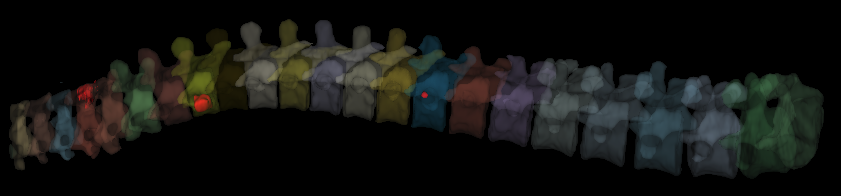

In [15]:
data_dir = os.path.join(BASE_PATH, "verteb_data")
display(Image(filename=os.path.join(data_dir, "vertebral_example.png")))

## 2. Load NIfTI Data
We load the reference lesion mask, predicted lesion mask, and the anatomical vertebra mask directly from the `./verteb_data` directory.

In [16]:
ref_path = os.path.join(data_dir, "reference.nii.gz")
pred_path = os.path.join(data_dir, "pred.nii.gz")
anatomy_path = os.path.join(data_dir, "verteb_segments.nii.gz")

ref_nii = nib.load(ref_path)
pred_nii = nib.load(pred_path)
anatomy_nii = nib.load(anatomy_path)

ref_mask = ref_nii.get_fdata().astype(np.uint8)
pred_mask = pred_nii.get_fdata().astype(np.uint8)
verteb_anatomy = anatomy_nii.get_fdata().astype(np.uint8)

# Extract voxel spacing from header for accurate distance metrics (like NSD/HD95)
voxelspacing = ref_nii.header.get_zooms()[:3]

print("Data loaded successfully!")
print(f"Reference shape: {ref_mask.shape}, labels: {np.unique(ref_mask)}")
print(f"Prediction shape: {pred_mask.shape}, labels: {np.unique(pred_mask)}")
print(f"Anatomy labels: {np.unique(verteb_anatomy)}")
print(f"Voxel spacing: {voxelspacing}")

Data loaded successfully!
Reference shape: (512, 512, 1031), labels: [0 1]
Prediction shape: (512, 512, 1031), labels: [0 1]
Anatomy labels: [ 0  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
Voxel spacing: (0.7246094, 0.7246094, 0.6)


## 3. Global Lesion Evaluation & Matching Strategies

Vertebra lesions are often challenging for automatic segmentation due to their heterogeneity and small size. This makes them particularly challenging for **Global Panoptic Quality (PQ)** evaluation.

We define a `SegmentationClassGroups` mapping to label 1.
We will compare three different matching strategies to highlight their impact on evaluation:
1. **Greedy 1:1 Matching (`NaiveThresholdMatching`)**: Iteratively pairs the first overlapping instances that beat the threshold. Can be suboptimal in dense lesion clusters.
2. **Optimal 1:1 Matching (`MaxBipartiteMatching`)**: Solves the global assignment problem to find the optimal 1:1 pairing that maximizes total IoU.
3. **Flexible N:1 Matching (`MaximizeMergeMatching`)**: Allows multiple fragmented predictions to merge and match a single ground-truth lesion, gracefully handling oversegmentation.

In [17]:
# Define the segmentation group (Label 1 = Lesion)
global_groups = SegmentationClassGroups({"Lesion": LabelGroup(1)})

print("--- Greedy 1:1 Matching (NaiveThreshold, IoU > 0.1) ---")
evaluator_naive = Panoptica_Evaluator(
    expected_input=InputType.SEMANTIC,
    instance_approximator=ConnectedComponentsInstanceApproximator(),
    instance_matcher=NaiveThresholdMatching(
        matching_metric=Metric.IOU, matching_threshold=0.1
    ),
    segmentation_class_groups=global_groups,
)

res_naive_all = evaluator_naive.evaluate(
    pred_mask, ref_mask, voxelspacing=voxelspacing, verbose=False
)
res_naive = res_naive_all.get("Lesion", list(res_naive_all.values())[0])

print(f"PQ: {res_naive.pq:.4f} | SQ: {res_naive.sq:.4f} | RQ: {res_naive.rq:.4f}")
print(f"TP: {res_naive.tp} | FP: {res_naive.fp} | FN: {res_naive.fn}\n")


print("--- Optimal 1:1 Matching (MaxBipartite, IoU > 0.1) ---")
evaluator_strict = Panoptica_Evaluator(
    expected_input=InputType.SEMANTIC,
    instance_approximator=ConnectedComponentsInstanceApproximator(),
    instance_matcher=MaxBipartiteMatching(
        matching_metric=Metric.IOU, matching_threshold=0.1
    ),
    segmentation_class_groups=global_groups,
)

res_strict_all = evaluator_strict.evaluate(
    pred_mask, ref_mask, voxelspacing=voxelspacing, verbose=False
)
res_strict = res_strict_all.get("Lesion", list(res_strict_all.values())[0])

print(f"PQ: {res_strict.pq:.4f} | SQ: {res_strict.sq:.4f} | RQ: {res_strict.rq:.4f}")
print(f"TP: {res_strict.tp} | FP: {res_strict.fp} | FN: {res_strict.fn}\n")


print("--- Flexible N:1 Matching (MaximizeMerge, IoU > 0.1) ---")
evaluator_flex = Panoptica_Evaluator(
    expected_input=InputType.SEMANTIC,
    instance_approximator=ConnectedComponentsInstanceApproximator(),
    instance_matcher=MaximizeMergeMatching(
        matching_metric=Metric.IOU, matching_threshold=0.1
    ),
    segmentation_class_groups=global_groups,
)

res_flex_all = evaluator_flex.evaluate(
    pred_mask, ref_mask, voxelspacing=voxelspacing, verbose=False
)
res_flex = res_flex_all.get("Lesion", list(res_flex_all.values())[0])

print(f"PQ: {res_flex.pq:.4f} | SQ: {res_flex.sq:.4f} | RQ: {res_flex.rq:.4f}")
print(f"TP: {res_flex.tp} | FP: {res_flex.fp} | FN: {res_flex.fn}")

--- Greedy 1:1 Matching (NaiveThreshold, IoU > 0.1) ---
PQ: 0.4845 | SQ: 0.6784 | RQ: 0.7143
TP: 15 | FP: 8 | FN: 4

--- Optimal 1:1 Matching (MaxBipartite, IoU > 0.1) ---
PQ: 0.4845 | SQ: 0.6784 | RQ: 0.7143
TP: 15 | FP: 8 | FN: 4

--- Flexible N:1 Matching (MaximizeMerge, IoU > 0.1) ---
PQ: 0.5374 | SQ: 0.6807 | RQ: 0.7895
TP: 15 | FP: 4 | FN: 4


## 4. Simple Semantic Segementation

In [19]:
evaluator = Panoptica_Evaluator(
    expected_input=InputType.SEMANTIC,
    instance_approximator=ConnectedComponentsInstanceApproximator(),
    instance_matcher=NaiveThresholdMatching(),
)

# print all results
result = evaluator.evaluate(pred_mask, ref_mask, verbose=False)["ungrouped"]
print(result)


+++ MATCHING +++
Number of instances in reference (n_ref_instances): 19
Number of instances in prediction (n_pred_instances): 23
True Positives (tp): 14
False Positives (fp): 9
False Negatives (fn): 5
Recognition Quality / F1-Score (rq): 0.6666666666666666

+++ GLOBAL +++
Global Binary Dice (global_bin_dsc): 0.8282655246252677

+++ INSTANCE +++
Segmentation Quality IoU (sq): 0.7168009104019986 +- 0.13276536485497187
Panoptic Quality IoU (pq): 0.47786727360133235
Segmentation Quality Dsc (sq_dsc): 0.8281701852851214 +- 0.08906381781253059
Panoptic Quality Dsc (pq_dsc): 0.5521134568567476
Segmentation Quality ASSD (sq_assd): 0.7799511609336064 +- 0.4816085772137235
Segmentation Quality Relative Volume Difference (sq_rvd): -0.11475966334559162 +- 0.17423258730010882



## 5. Region-Wise Anatomical Evaluation (Parts)

When lesions span multiple vertebrae or are tightly packed, evaluating performance *locally* within each vertebra provides deeper clinical insight. Here, the individual vertebrae act as our **"Parts"**.

We map the binary lesions to their corresponding anatomical segments. By creating a `LabelGroup` for each vertebra, Panoptica evaluates each region independently.

In [20]:
# Create anatomy-aware masks: Lesion voxels inherit the vertebra segment ID
ref_anatomy_mask = np.where(ref_mask == 1, verteb_anatomy, 0).astype(np.uint8)
pred_anatomy_mask = np.where(pred_mask == 1, verteb_anatomy, 0).astype(np.uint8)

# Dynamically define a group for each unique anatomical segment present
unique_segments = np.unique(verteb_anatomy)
unique_segments = unique_segments[unique_segments > 0]  # Ignore background

segment_groups_dict = {}
for i in unique_segments:
    # Ensure 'i' is converted from a NumPy type to a native Python integer.
    # LabelGroup expects an int, and passing a numpy scalar causes an iterable TypeError under the hood.
    segment_groups_dict[f"Vertebra_{i}"] = LabelGroup(int(i))

regional_groups = SegmentationClassGroups(segment_groups_dict)

evaluator_regional = Panoptica_Evaluator(
    expected_input=InputType.SEMANTIC,
    instance_approximator=ConnectedComponentsInstanceApproximator(),
    instance_matcher=MaximizeMergeMatching(
        matching_metric=Metric.IOU, matching_threshold=0.1
    ),
    segmentation_class_groups=regional_groups,
)

results_regional = evaluator_regional.evaluate(
    pred_anatomy_mask, ref_anatomy_mask, voxelspacing=voxelspacing, verbose=False
)

print(
    f"{'Region':<12} | {'PQ':<6} | {'SQ':<6} | {'RQ':<6} | "
    f"{'TP':<4} | {'FP':<4} | {'FN':<4}"
)
print("-" * 55)
for name, res in results_regional.items():
    # Only print segments that actually have ground truth or predictions to keep it clean
    if res.tp + res.fp + res.fn > 0:
        print(
            f"{name:<12} | {res.pq:.4f} | {res.sq:.4f} | {res.rq:.4f} | "
            f"{res.tp:<4} | {res.fp:<4} | {res.fn:<4}"
        )

Region       | PQ     | SQ     | RQ     | TP   | FP   | FN  
-------------------------------------------------------
vertebra_11  | 0.5290 | 0.5290 | 1.0000 | 1    | 0    | 0   
vertebra_14  | 0.9136 | 0.9136 | 1.0000 | 2    | 0    | 0   
vertebra_15  | 0.5344 | 0.5344 | 1.0000 | 1    | 0    | 0   
vertebra_17  | 0.3027 | 0.5044 | 0.6000 | 3    | 1    | 3   
vertebra_18  | 0.8938 | 0.8938 | 1.0000 | 1    | 0    | 0   
vertebra_21  | 0.7043 | 0.7043 | 1.0000 | 2    | 0    | 0   
vertebra_22  | 0.3949 | 0.5923 | 0.6667 | 1    | 0    | 1   
vertebra_23  | 0.6420 | 0.6420 | 1.0000 | 1    | 0    | 0   
vertebra_24  | 0.5238 | 0.7856 | 0.6667 | 2    | 2    | 0   
vertebra_25  | 0.6346 | 0.9519 | 0.6667 | 1    | 1    | 0   


## 6. Threshold Analysis and AUTC

Spinal lesions can be very small, meaning a shift of just 1-2 voxels causes IoU to plummet. Instead of relying on a single, arbitrary threshold, we sweep the threshold and calculate the **Area Under Threshold Curve (AUTC)**: $AUTC = \int_{0}^{1} PQ(\tau) d\tau$. This provides a highly robust metric for overall performance.

Sweeping thresholds for Global Lesion Evaluation...
  [IoU >= 0.05] PQ=0.5374 | TP=15
  [IoU >= 0.10] PQ=0.5374 | TP=15
  [IoU >= 0.15] PQ=0.5300 | TP=14
  [IoU >= 0.20] PQ=0.5300 | TP=14
  [IoU >= 0.25] PQ=0.5300 | TP=14
  [IoU >= 0.30] PQ=0.5300 | TP=14
  [IoU >= 0.35] PQ=0.5300 | TP=14
  [IoU >= 0.40] PQ=0.5300 | TP=14
  [IoU >= 0.45] PQ=0.5300 | TP=14
  [IoU >= 0.50] PQ=0.5300 | TP=14
  [IoU >= 0.55] PQ=0.4743 | TP=12
  [IoU >= 0.60] PQ=0.4432 | TP=11
  [IoU >= 0.65] PQ=0.4094 | TP=10
  [IoU >= 0.70] PQ=0.2092 | TP=5
  [IoU >= 0.75] PQ=0.2092 | TP=5
  [IoU >= 0.80] PQ=0.1719 | TP=4
  [IoU >= 0.85] PQ=0.1719 | TP=4
  [IoU >= 0.90] PQ=0.0870 | TP=2
  [IoU >= 0.95] PQ=0.0000 | TP=0


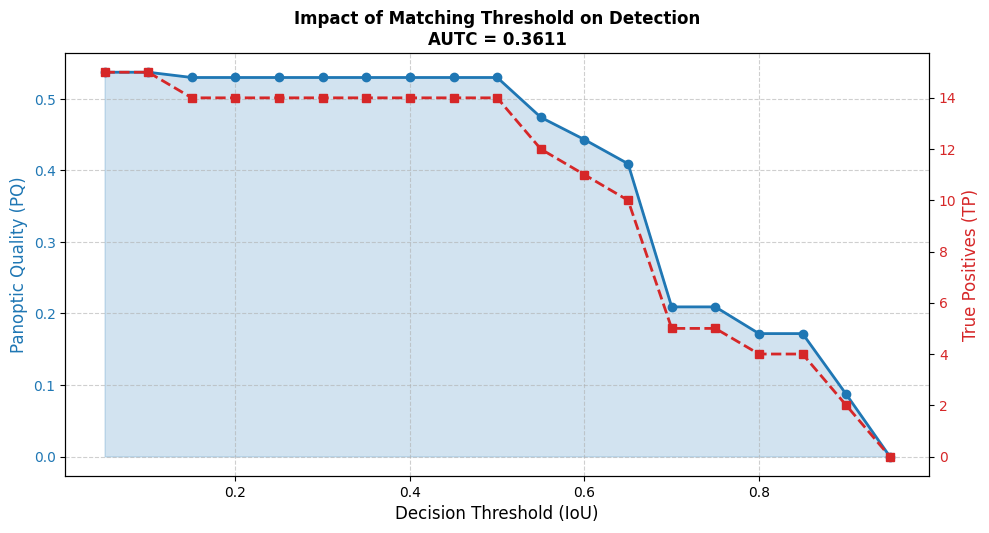

Final AUTC Score: 0.3611
AUTC captures the model's true performance spectrum, proving highly robust against the tiny-instance penalty.


In [21]:
thresholds = np.arange(0.05, 1.0, 0.05)
pq_scores = []
tp_counts = []

print("Sweeping thresholds for Global Lesion Evaluation...")
for thresh in thresholds:
    matcher = MaximizeMergeMatching(
        matching_metric=Metric.IOU, matching_threshold=float(thresh)
    )

    ev = Panoptica_Evaluator(
        expected_input=InputType.SEMANTIC,
        instance_approximator=ConnectedComponentsInstanceApproximator(),
        instance_matcher=matcher,
        segmentation_class_groups=global_groups,
    )

    r_all = ev.evaluate(pred_mask, ref_mask, voxelspacing=voxelspacing, verbose=False)
    r = r_all.get("Lesion", list(r_all.values())[0])

    pq_scores.append(r.pq)
    tp_counts.append(r.tp)
    print(f"  [IoU >= {thresh:.2f}] PQ={r.pq:.4f} | TP={r.tp}")

# Calculate Area Under the Curve (using trapezoidal rule from sklearn)
autc_score = auc(thresholds, pq_scores)

# Plotting the degradation curves and AUTC
fig, ax1 = plt.subplots(figsize=(10, 5))

color = "tab:blue"
ax1.set_xlabel("Decision Threshold (IoU)", fontsize=12)
ax1.set_ylabel("Panoptic Quality (PQ)", color=color, fontsize=12)
ax1.plot(thresholds, pq_scores, marker="o", color=color, linewidth=2)
ax1.fill_between(thresholds, pq_scores, alpha=0.2, color=color)  # Fill for AUTC visual
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.6)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("True Positives (TP)", color=color, fontsize=12)
ax2.plot(thresholds, tp_counts, marker="s", linestyle="--", color=color, linewidth=2)
ax2.tick_params(axis="y", labelcolor=color)

fig.tight_layout()
plt.title(
    f"Impact of Matching Threshold on Detection\nAUTC = {autc_score:.4f}",
    fontweight="bold",
)
plt.show()

print(f"Final AUTC Score: {autc_score:.4f}")
print(
    "AUTC captures the model's true performance spectrum, proving highly robust against "
    "the tiny-instance penalty."
)